In [1]:
import pandas as pd
 
df = pd.read_csv("employee_benefits_claims_dummy_dataset.csv")
 
df.head()

,Employee_ID,Employee_Name,Department,Claim_Type,Claim_Amount,Approved_Amount,Claim_Status,Claim_Date,Approval_Date,Payment_Status,Payment_Method,Vendor
0,1000,Priya Sharma,Finance,Medical,12179,11195,Approved,2023-02-14,2023-02-24,Unpaid,Bank Transfer,Max Healthcare
1,1001,Arjun Khanna,HR,Pharmacy,13171,0,Pending,2024-01-09,2024-01-11,Unpaid,Bank Transfer,Local Clinic
2,1002,Arjun Kapoor,Finance,Medical,5077,0,Pending,2024-03-31,2024-04-10,Unpaid,Payroll,Fortis
3,1003,Pooja Sharma,Sales,Medical,12298,0,Pending,2024-05-24,2024-05-28,Unpaid,Payroll,Apollo Hospital
4,1004,Sneha Khanna,Operations,Dental,11942,0,Pending,2023-05-26,2023-06-05,Unpaid,Bank Transfer,Apollo Hospital


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Employee_ID      1000 non-null   int64
 1   Employee_Name    1000 non-null   str  
 2   Department       1000 non-null   str  
 3   Claim_Type       1000 non-null   str  
 4   Claim_Amount     1000 non-null   int64
 5   Approved_Amount  1000 non-null   int64
 6   Claim_Status     1000 non-null   str  
 7   Claim_Date       1000 non-null   str  
 8   Approval_Date    1000 non-null   str  
 9   Payment_Status   1000 non-null   str  
 10  Payment_Method   1000 non-null   str  
 11  Vendor           1000 non-null   str  
dtypes: int64(3), str(9)
memory usage: 93.9 KB


In [4]:
df.describe()

,Employee_ID,Claim_Amount,Approved_Amount
count,1000.000000,1000.000000,1000.000000
mean,1499.500000,9890.684000,3201.850000
std,288.819436,5629.457117,5583.067951
min,1000.000000,512.000000,-347.000000
25%,1249.750000,5047.750000,0.000000
50%,1499.500000,9755.500000,0.000000
75%,1749.250000,14778.000000,4687.250000
max,1999.000000,19988.000000,19830.000000


In [5]:
df['Department'].value_counts()

Department
Operations    179
Finance       171
Marketing     166
IT            163
Sales         162
HR            159
Name: count, dtype: int64

In [8]:
df.groupby("Claim_Type")["Claim_Amount"].sum()

Claim_Type
Dental       1915475
Medical      2028640
Pharmacy     2254883
Transport    1907512
Wellness     1784174
Name: Claim_Amount, dtype: int64

In [10]:
df.groupby("Department")["Claim_Amount"].sum()

Department
Finance       1672651
HR            1632846
IT            1686875
Marketing     1640513
Operations    1639482
Sales         1618317
Name: Claim_Amount, dtype: int64

In [11]:
df["Claim_Status"].value_counts()

Claim_Status
Rejected    342
Approved    331
Pending     327
Name: count, dtype: int64

In [13]:
df["Claim_Date"] = pd.to_datetime(df["Claim_Date"])

In [15]:
df.groupby(df["Claim_Date"].dt.to_period("M")).size()

Claim_Date
2023-01    51
2023-02    56
2023-03    56
2023-04    50
2023-05    54
2023-06    58
2023-07    41
2023-08    48
2023-09    42
2023-10    64
2023-11    39
2023-12    49
2024-01    41
2024-02    51
2024-03    65
2024-04    52
2024-05    52
2024-06    47
2024-07    48
2024-08    36
Freq: M, dtype: int64

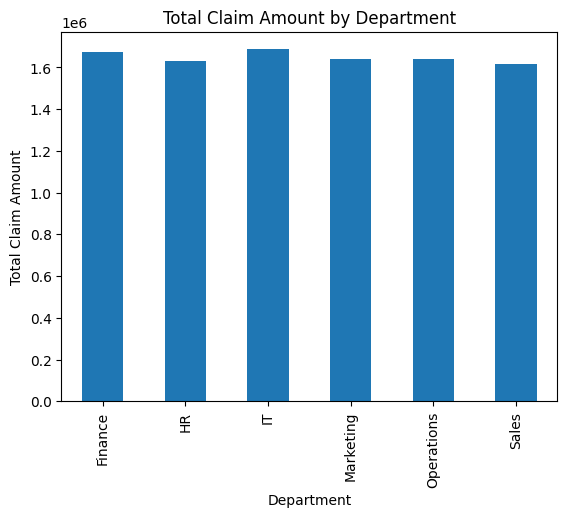

In [16]:
import matplotlib.pyplot as plt
 
df.groupby("Department")["Claim_Amount"].sum().plot(kind="bar")
 
plt.title("Total Claim Amount by Department")
plt.xlabel("Department")
plt.ylabel("Total Claim Amount")
 
plt.show()

In [17]:
df.to_csv("claims_cleaned_data.csv", index=False)